### 라이브러리 설치 및 Import

In [162]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


## 시각화

In [163]:
df = pd.read_csv('../../Data/merged_df.csv')

In [164]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   person            306137 non-null  str    
 1   event             306137 non-null  str    
 2   time              306137 non-null  int64  
 3   offer_id          167184 non-null  str    
 4   amount            138953 non-null  float64
 5   bonus_reward      33182 non-null   float64
 6   time_days         306137 non-null  int64  
 7   gender            306137 non-null  str    
 8   age               272388 non-null  float64
 9   customer_id       306137 non-null  str    
 10  became_member_on  306137 non-null  str    
 11  income            272388 non-null  float64
 12  income_missing    306137 non-null  int64  
 13  age_missing       306137 non-null  int64  
 14  reward            167184 non-null  float64
 15  difficulty        167184 non-null  float64
 16  duration          167184 non-nu

In [209]:
df.tail(50)

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label
306087,a4c2dd694269444085976f10b9b225f6,transaction,714,NaN,28.58,NaN,30,M,66.0,a4c2dd694269444085976f10b9b225f6,2015-10-30,72000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306088,4b59509988d34c7298119a840c946453,transaction,714,NaN,0.06,NaN,30,M,42.0,4b59509988d34c7298119a840c946453,2017-12-21,59000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306089,92153f7cdda8486b9a2214ceb11b1a17,transaction,714,NaN,4.39,NaN,30,M,52.0,92153f7cdda8486b9a2214ceb11b1a17,2016-09-12,50000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306090,3c88696ac23741cb8a709d656fe5ccdf,transaction,714,NaN,25.76,NaN,30,M,50.0,3c88696ac23741cb8a709d656fe5ccdf,2016-05-30,86000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306091,1b24e887d980450497b631d8756128e6,transaction,714,NaN,0.35,NaN,30,M,39.0,1b24e887d980450497b631d8756128e6,2013-08-20,47000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306092,1c71315203b746b786c43ce12d7e97fe,transaction,714,NaN,20.84,NaN,30,M,37.0,1c71315203b746b786c43ce12d7e97fe,2017-12-26,86000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306093,abc4359eb34e4e2ca2349da2ddf771b6,viewed,714,3f207df678b143eea3cee63160fa8bed,NaN,NaN,30,M,51.0,abc4359eb34e4e2ca2349da2ddf771b6,2014-08-04,68000.0,0,0,0.0,0.0,4.0,1.0,1.0,1.0,0.0,informational_1
306094,693082e8ccf9458a88c428779cf556a6,transaction,714,NaN,2.16,NaN,30,M,69.0,693082e8ccf9458a88c428779cf556a6,2014-01-09,69000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306095,d4f6205a98b4420082aae16e5a93655a,transaction,714,NaN,1.22,NaN,30,M,19.0,d4f6205a98b4420082aae16e5a93655a,2017-10-22,57000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306096,7b2939e61c324b2087328c4b6fee2632,transaction,714,NaN,26.41,NaN,30,F,78.0,7b2939e61c324b2087328c4b6fee2632,2017-12-20,92000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### informational event 처리

#### bonus_reward가 존재하는 데이터는 모두 completed 인가?

In [165]:
# bonus_reward가 있으면 completed인지 검증
bonus_rows = df[df['bonus_reward'].notna()].copy()

print("bonus_reward 기록 행 수:", len(bonus_rows))
print()
print("event 분포:")
print(bonus_rows['event'].value_counts(dropna=False))
print()
print("모두 completed인가?:", (bonus_rows['event'] == 'completed').all())

bonus_reward 기록 행 수: 33182

event 분포:
event
completed    33182
Name: count, dtype: int64

모두 completed인가?: True


In [166]:
# completed이면 bonus_reward가 있는지 검증
completed_rows = df[df['event'] == 'completed'].copy()

print("completed 기록 행 수:", len(completed_rows))
print()
print("event 분포:")
print(completed_rows['bonus_reward'].value_counts(dropna=False))
print()
print("모두 bonus_reward가 있는가?:", (completed_rows['bonus_reward'].notna()).all())

completed 기록 행 수: 33182

event 분포:
bonus_reward
5.0     11905
2.0      9229
10.0     6936
3.0      5112
Name: count, dtype: int64

모두 bonus_reward가 있는가?: True


#### informational 기록은 모두 거래 completed가 없을까?

In [167]:
# informational이면 completed가 없는지 검증
informational_rows = df[df['offer_label'].str.contains('informational')].copy()

print("informational 기록 행 수:", len(informational_rows))
print()
print("event 분포:")
print(informational_rows['event'].value_counts(dropna=False))
print()
print("모두 completed가 아닌가?:", (informational_rows['event'] != 'completed').all())

informational 기록 행 수: 26066

event 분포:
event
received    15235
viewed      10831
Name: count, dtype: int64

모두 completed가 아닌가?: True


> 오퍼 단위에서는 informational을 포함한 offer_label도 고려  
> 거래 단위에서는 informational을 포함한 offer_label은 고려 X 

In [208]:
# amount가 있으면 completed인지 검증
amount_rows = df[df['amount'].notna()].copy()

print("amount_reward 기록 행 수:", len(amount_rows))
print()
print("event 분포:")
print(amount_rows['event'].value_counts(dropna=False))
print()
print("모두 completed인가?:", (amount_rows['event'] == 'completed').all())

amount_reward 기록 행 수: 138953

event 분포:
event
transaction    138953
Name: count, dtype: int64

모두 completed인가?: False


### 전체(핵심 지표 소개)

#### 총 오퍼 퍼널 분석

In [168]:
# 총 발송 수
cnt_received = df['customer_id'][df['event']=='received'].count()
print("총 발송 수:")
print(cnt_received)

총 발송 수:
76277


In [169]:
# 총 열람 수
cnt_viewed = df['customer_id'][df['event']=='viewed'].count()
print("총 열람 수:")
print(cnt_viewed)

총 열람 수:
57725


In [170]:
# 총 완료 수
cnt_completed = df['customer_id'][df['event']=='completed'].count()
print("총 완료 수:")
print(cnt_completed)

총 완료 수:
33182


In [171]:
# 발송 → 열람 전환율
ratio_received_viewed = cnt_viewed / cnt_received * 100
print("발송 → 열람 전환율:")
print(f'{ratio_received_viewed:.2f}%')

발송 → 열람 전환율:
75.68%


In [172]:
# 열람 → 완료 전환율
ratio_viewed_completed = cnt_completed / cnt_viewed * 100
print("열람 → 완료 전환율:")
print(f'{ratio_viewed_completed:.2f}%')

열람 → 완료 전환율:
57.48%


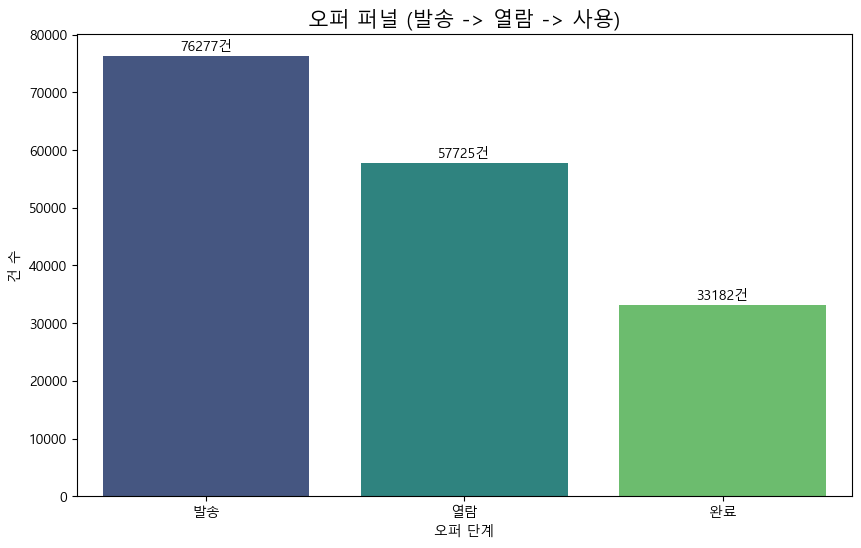

In [206]:
offer_events = ['received', 'viewed', 'completed']
funnel_df = df[df['event'].isin(offer_events)]

overall_funnel = funnel_df['event'].value_counts().reindex(offer_events)

# 영문 → 한글 매핑
label_map = {
    'received': '발송',
    'viewed': '열람',
    'completed': '완료'
}

x_labels = [label_map[x] for x in overall_funnel.index]

# 시각화 1: 전체 퍼널 현황
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=x_labels, y=overall_funnel.values, palette='viridis')

plt.title('오퍼 퍼널 (발송 -> 열람 -> 사용)', fontsize=15)
plt.ylabel('건 수')
plt.xlabel('오퍼 단계')

# 막대 위에 값 표시
for i, v in enumerate(overall_funnel):
    ax.text(i, v + 1000, f"{v:.0f}건", ha='center')

plt.show()

#### 전체 매출 관련

In [174]:
# 구매 데이터만 추출
transactions = df[df['event'] == 'transaction'].copy()

In [175]:
# 총 매출
total_revenue = transactions['amount'].sum()
print("총 매출:")
print(f'${total_revenue:,.0f}')

총 매출:
$1,775,452


In [176]:
# 총 거래 건수
cnt_transaction = len(transactions)
print("총 거래 건수:")
print(f'{cnt_transaction:,}건')

총 거래 건수:
138,953건


In [177]:
transactions['amount'].describe()

count    138953.000000
mean         12.777356
std          30.250529
min           0.050000
25%           2.780000
50%           8.890000
75%          18.070000
max        1062.280000
Name: amount, dtype: float64

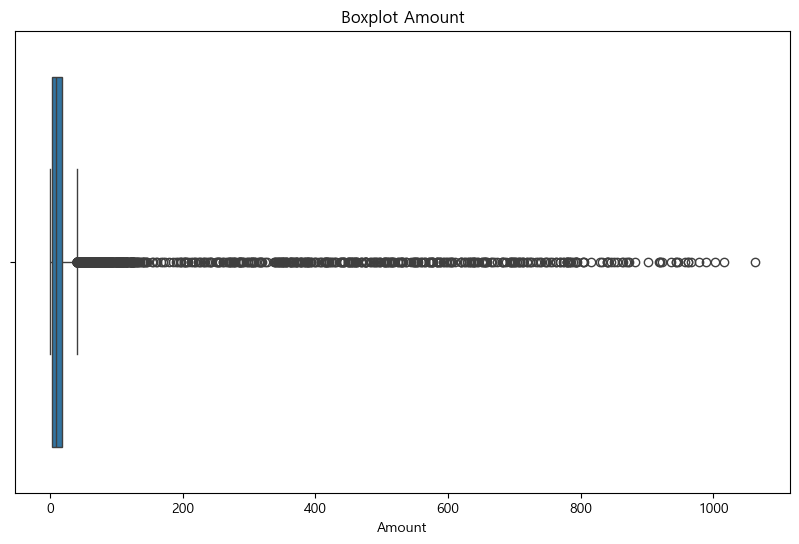

In [178]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=transactions['amount'].dropna())
plt.title('Boxplot Amount')
plt.xlabel('Amount')
plt.show()

#### 고유 고객 수

In [179]:
# 고유 고객 수
cnt_customer_unique = df['customer_id'].nunique()

print("고유 고객 수:")
print(f'{cnt_customer_unique:,}명')

고유 고객 수:
17,000명


> 17,000명에 대한 1개월 치 offer 정보를 줬을지도?

#### 구매 고객 수

In [180]:
# 구매 고객 수
cnt_buyer = transactions['customer_id'].nunique()

print("구매 고객 수:")
print(f'{cnt_buyer:,}명')

구매 고객 수:
16,578명


#### 객단가(AOV) = 총 매출 / 총 거래 건수

In [181]:
# 객단가(AOV - Average order value, 거래별 객단가) = 총 매출 / 총 거래 건수
aov = total_revenue / cnt_transaction
print("객단가(AOV):")
print(f'${aov:,.2f}')

객단가(AOV):
$12.78


#### 고객 가치 = 총 매출 / 고객 수 → 객단가?

In [182]:
# 전체 고객별 객단가(ARPU - Average Revenue Per User) = 총 매출 / 전체 고객 수
# customer_value_all ??

total_cnt_customer = transactions['customer_id'].count()

arpu = total_revenue / cnt_customer_unique
print("객단가(ARPU):")
print(f'${arpu:,.2f}')

객단가(ARPU):
$104.44


In [183]:
# 구매 고객별 객단가(ARPU - Average Revenue Per Paying User) = 총 매출 / 구매 고객 수
# customer_value_buyers ??

arppu = total_revenue / cnt_buyer
print("객단가(ARPPU):")
print(f'${arppu:,.2f}')

객단가(ARPPU):
$107.10


#### 채널별 offer 고객 수(중복 O): 1개 offer에 제공되는 채널이 여러 개이므로

In [184]:
# 채널별 고객 수
cnt_web_customer = df['customer_id'][df['web']==1].count()
cnt_email_customer = df['customer_id'][df['email']==1].count()
cnt_mobile_customer = df['customer_id'][df['mobile']==1].count()
cnt_social_customer = df['customer_id'][df['social']==1].count()

print("채널별 고객 수:")
print(f'web: {cnt_web_customer:,}명')
print(f'email: {cnt_email_customer:,}명')
print(f'mobile: {cnt_mobile_customer:,}명')
print(f'social: {cnt_social_customer:,}명')

채널별 고객 수:
web: 134,870명
email: 167,184명
mobile: 153,513명
social: 109,887명


> 발송이 되어야만 열람/완료가 진행되는 구조라면,  
> 발송 기록이 있는 고객만 count를 해서 채널별 데이터 중복을 막을 수 있음

#### 전체 기록 고객 수

In [185]:
# 전체 기록 고객 수(중복 O)
cnt_customer = df['customer_id'].count()

print("전체 고객 수:")

print(f'{cnt_customer:,}명')

전체 고객 수:
306,137명


> 발송이 되어야만 열람/완료가 진행되는 구조라면,  
> 발송 기록이 있는 고객만 count를 해서 채널별 데이터 중복을 막을 수 있음

In [186]:
received_df = df[df['event'] == 'received']

receive_counts = received_df.groupby(['customer_id', 'offer_id']).size().reset_index(name='receive_count')

multiple_receives = receive_counts[receive_counts['receive_count'] > 1]

print(f"2번 이상: {len(multiple_receives)}건")
print(multiple_receives.head(100))

2번 이상: 11718건
                          customer_id                          offer_id  \
5    00116118485d4dfda04fdbaba9a87b5c  f19421c1d4aa40978ebb69ca19b0e20d   
14   0020c2b971eb4e9188eac86d93036a77  fafdcd668e3743c1bb461111dcafc2a4   
22   003d66b6608740288d6cc97a6903f4f0  fafdcd668e3743c1bb461111dcafc2a4   
24   00426fe3ffde4c6b9cb9ad6d077a13ea  2906b810c7d4411798c6938adc9daaa5   
31   004c5799adbf42868b9cff0396190900  f19421c1d4aa40978ebb69ca19b0e20d   
32   004c5799adbf42868b9cff0396190900  fafdcd668e3743c1bb461111dcafc2a4   
35   005500a7188546ff8a767329a2f7c76a  ae264e3637204a6fb9bb56bc8210ddfd   
46   0069a50874d846438e58acff5e594725  2906b810c7d4411798c6938adc9daaa5   
48   00715b6e55c3431cb56ff7307eb19675  0b1e1539f2cc45b7b9fa7c272da2e1d7   
53   0082fd87c18f45f2be70dbcbb0fb8aad  3f207df678b143eea3cee63160fa8bed   
55   0082fd87c18f45f2be70dbcbb0fb8aad  9b98b8c7a33c4b65b9aebfe6a799e6d9   
57   00840a2ca5d2408e982d56544dc14ffd  2906b810c7d4411798c6938adc9daaa5   
68   008d70

#### 고객 생애 가치  
> offer 시작일 기준으로 30일차까지 밖에 없어서 생애 전체를 보기에 한계가 있음을 인식하고 진행

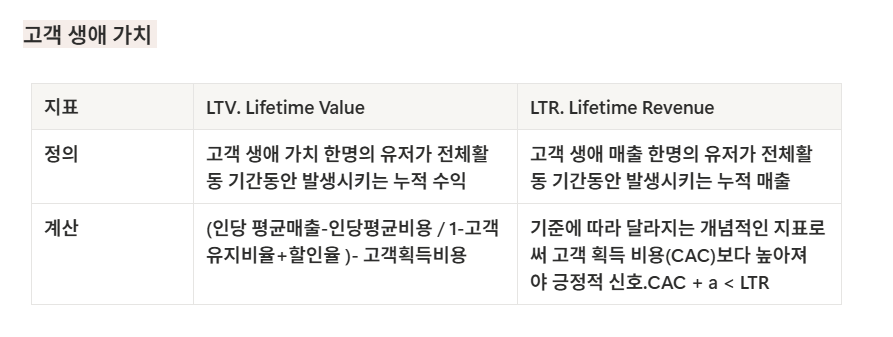

In [187]:
# 인당 평균 비용 = 총 비용 / 총 고객 수

# 고객에게 제공하는 reward의 총 합을 총 비용으로 계산
total_cost = df['reward'].sum()

avg_cost = total_cost / total_cnt_customer
print("인당 평균 비용:")
print(f'${avg_cost:,.2f}')

인당 평균 비용:
$5.32


In [188]:
# 인당 평균 순이익(매출-비용) = 총 고객별 객단가(인당 평균 매출) - 인당 평균 비용
avg_net = arpu - avg_cost
print("인당 평균 순이익:")
print(f'${avg_net:,.2f}')

인당 평균 순이익:
$99.12


> 현재 데이터셋에서 LTV 대체 값?

#### 평균 구매 빈도

In [189]:
# 평균 구매 빈도(전체 고객) = 총 거래 건수 / 전체 고객 수

avg_frequency_all = cnt_transaction / cnt_customer_unique
print("평균 구매 빈도(전체 고객):")
print(f'{avg_frequency_all:,.2f}')

평균 구매 빈도(전체 고객):
8.17


In [190]:
# 평균 구매 빈도(구매 고객) = 총 거래 건수 / 구매 고객 수

avg_frequency_buyers = cnt_transaction / cnt_buyer
print("평균 구매 빈도(구매 고객):")
print(f'{avg_frequency_buyers:,.2f}')

평균 구매 빈도(구매 고객):
8.38


In [191]:
print("[핵심 KPI 요약]")
print(f"고유 고객 수: {cnt_customer_unique:,}명")
print(f"구매 고객 수: {cnt_buyer:,}명")
print(f"총 거래 건수: {cnt_transaction:,}건")
print(f"총 매출: ${total_revenue:,.2f}")
print(f"평균 구매 빈도(전체 고객): {avg_frequency_all:,.2f}회")
print(f"평균 구매 빈도(구매 고객): {avg_frequency_buyers:,.2f}회")
print(f"객단가(AOV): ${aov:,.2f}")
print(f"고객 가치(전체 고객): ${arpu:,.2f}")
print(f"고객 가치(구매 고객): ${arppu:,.2f}")

[핵심 KPI 요약]
고유 고객 수: 17,000명
구매 고객 수: 16,578명
총 거래 건수: 138,953건
총 매출: $1,775,451.97
평균 구매 빈도(전체 고객): 8.17회
평균 구매 빈도(구매 고객): 8.38회
객단가(AOV): $12.78
고객 가치(전체 고객): $104.44
고객 가치(구매 고객): $107.10


In [192]:
# kpi_summary = pd.DataFrame({
#     '지표': [
#         '고유 고객 수',
#         '구매 고객 수',
#         '총 거래 건수',
#         '총 매출',
#         '평균 구매 빈도(전체 고객)',
#         '평균 구매 빈도(구매 고객)',
#         '객단가(AOV)',
#         '고객가치(전체 고객)',
#         '고객가치(구매 고객)'
#     ],
#     '값': [
#         cnt_customer_unique,
#         cnt_buyer,
#         cnt_transaction,
#         round(total_revenue, 2),
#         round(avg_frequency_all, 2),
#         round(avg_frequency_buyers, 2),
#         round(aov, 2),
#         round(arpu, 2),
#         round(arppu, 2)
#     ]
# })

# display(kpi_summary)

#### 고객별 구매 요약

In [193]:
# 고객별 구매 요약
customer_stats = (
    transactions.groupby('customer_id')['amount']
    .agg(['sum', 'count', 'mean'])
    .reset_index()
    .rename(columns={
        'sum': 'total_spend',
        'count': 'purchase_cnt',
        'mean': 'aov_customer'
    })
)

customer_stats.head()

,customer_id,total_spend,purchase_cnt,aov_customer
0,0009655768c64bdeb2e877511632db8f,127.60,8,15.950000
1,00116118485d4dfda04fdbaba9a87b5c,4.09,3,1.363333
2,0011e0d4e6b944f998e987f904e8c1e5,79.46,5,15.892000
3,0020c2b971eb4e9188eac86d93036a77,196.86,8,24.607500
4,0020ccbbb6d84e358d3414a3ff76cffd,154.05,12,12.837500


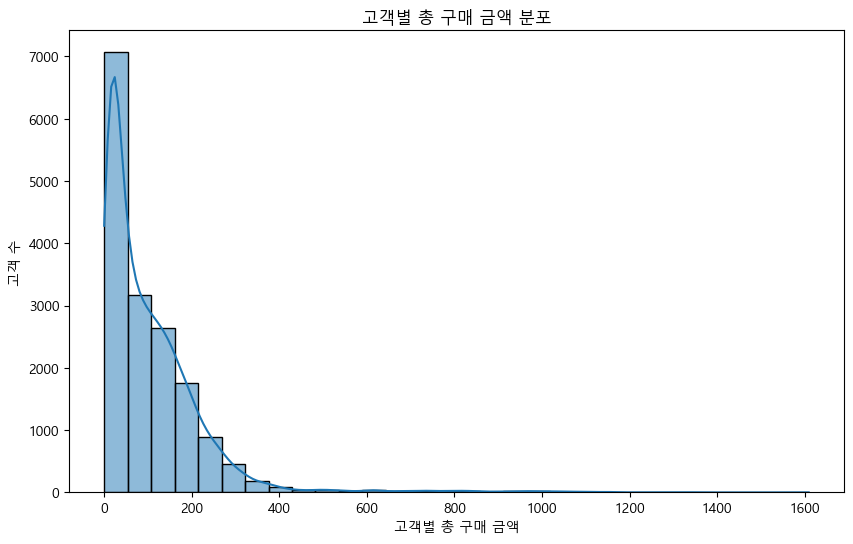

In [194]:
# 고객별 총 구매 금액 분포
plt.figure(figsize=(10, 6))
sns.histplot(customer_stats['total_spend'], bins=30, kde=True)
plt.title('고객별 총 구매 금액 분포')
plt.xlabel('고객별 총 구매 금액')
plt.ylabel('고객 수')
plt.show()

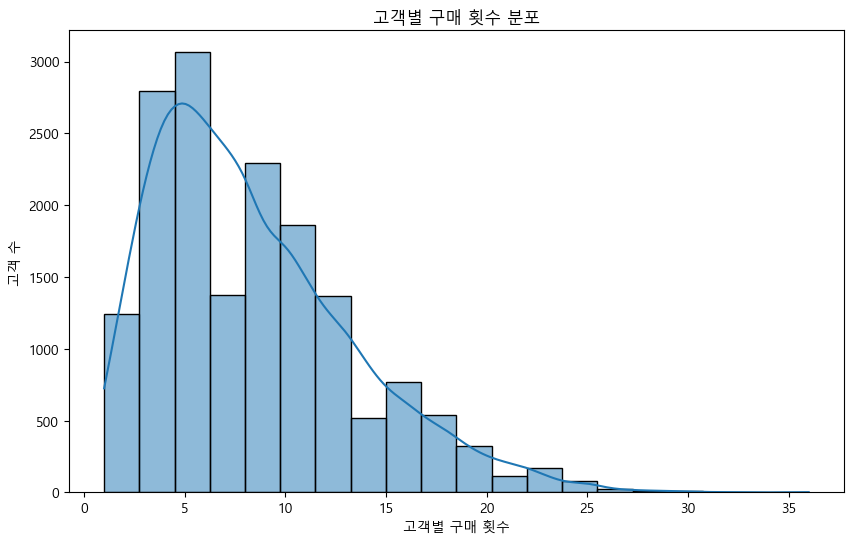

In [195]:
# 고객별 구매 횟수 분포
plt.figure(figsize=(10, 6))
sns.histplot(customer_stats['purchase_cnt'], bins=20, kde=True)
plt.title('고객별 구매 횟수 분포')
plt.xlabel('고객별 구매 횟수')
plt.ylabel('고객 수')
plt.show()

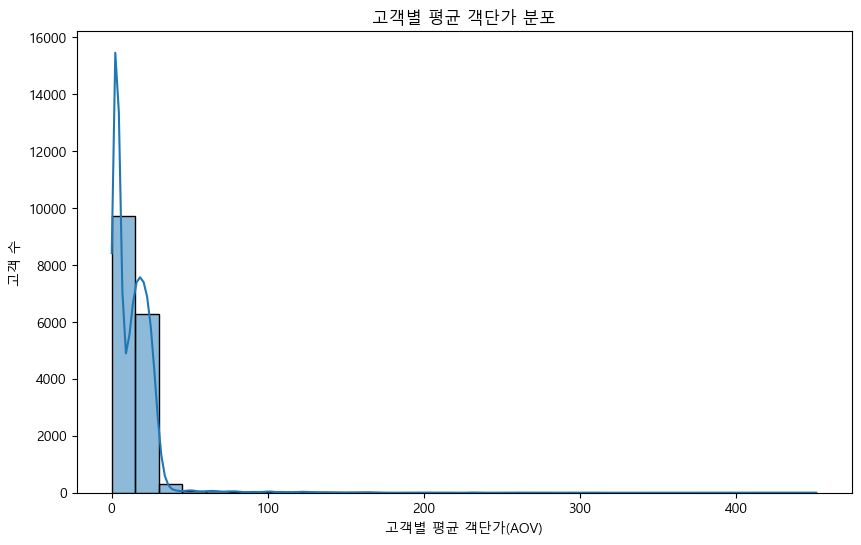

In [196]:
# 고객별 평균 객단가 분포
plt.figure(figsize=(10, 6))
sns.histplot(customer_stats['aov_customer'], bins=30, kde=True)
plt.title('고객별 평균 객단가 분포')
plt.xlabel('고객별 평균 객단가(AOV)')
plt.ylabel('고객 수')
plt.show()

#### 구매 상위 고객 분포 확인

In [197]:
# 구매 상위 고객 10명 추출
top_customers = customer_stats.sort_values('total_spend', ascending=False).head(10)
display(top_customers)

,customer_id,total_spend,purchase_cnt,aov_customer
3929,3c8d541112a74af99e88abbd0692f00e,1608.69,8,201.086250
15693,f1d65ae63f174b8f80fa063adcaa63b7,1365.66,13,105.050769
11422,ae6f43089b674728a50b8727252d3305,1327.74,16,82.983750
6366,626df8678e2a4953b9098246418c9cfa,1321.42,13,101.647692
7492,73afdeca19e349b98f09e928644610f8,1319.97,10,131.997000
5358,52959f19113e4241a8cb3bef486c6412,1292.86,12,107.738333
11334,ad1f0a409ae642bc9a43f31f56c130fc,1258.19,5,251.638000
13672,d240308de0ee4cf8bb6072816268582b,1251.99,14,89.427857
9673,946fc0d3ecc4492aa4cc06cf6b1492c3,1232.40,17,72.494118
6484,6406abad8e2c4b8584e4f68003de148d,1211.76,12,100.980000


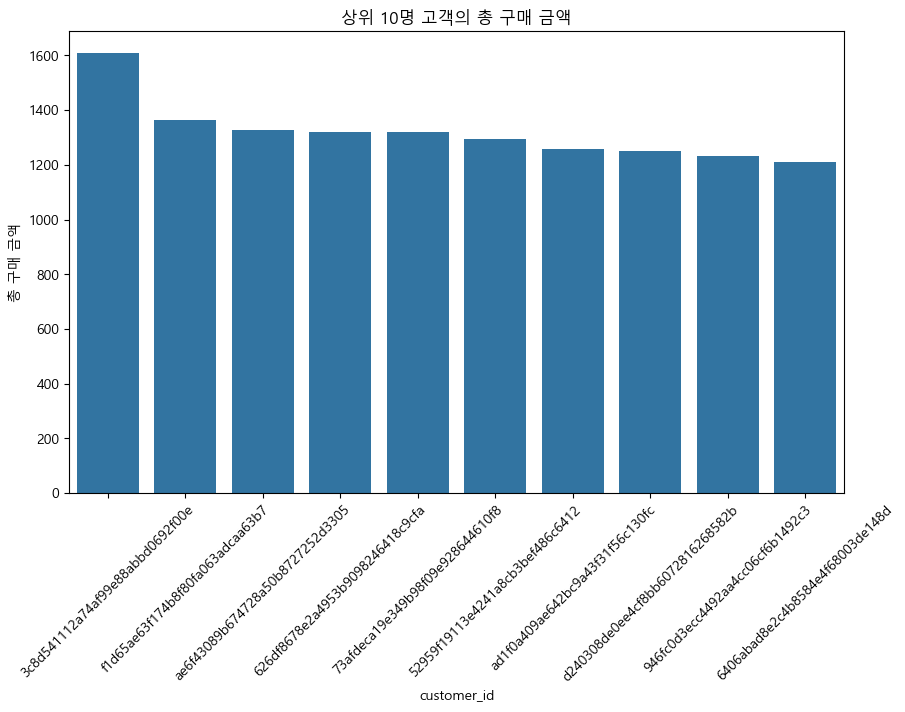

In [198]:
# 구매 상위 고객 10명의 총 구매 금액
plt.figure(figsize=(10, 6))
sns.barplot(data=top_customers, x='customer_id', y='total_spend')
plt.title('상위 10명 고객의 총 구매 금액')
plt.xlabel('customer_id')
plt.ylabel('총 구매 금액')
plt.xticks(rotation=45)
plt.show()

#### offer completed 여부별 구매 차이 확인

In [199]:
# offer completed 고객 목록
completed_customers = df.loc[df['event'] == 'completed', 'customer_id'].unique()

# 고객별 완료 여부
customer_stats['offer_completed'] = customer_stats['customer_id'].isin(completed_customers)

# 요약
offer_compare = (
    customer_stats.groupby('offer_completed', as_index=False)
    .agg(
        고객수=('customer_id', 'nunique'),
        평균총구매금액=('total_spend', 'mean'),
        평균구매횟수=('purchase_cnt', 'mean'),
        평균객단가=('aov_customer', 'mean')
    )
)

offer_compare['offer_completed'] = offer_compare['offer_completed'].map({
    True: '오퍼 완료 고객',
    False: '오퍼 미완료 고객'
})

display(offer_compare)

,offer_completed,고객수,평균총구매금액,평균구매횟수,평균객단가
0,오퍼 미완료 고객,3804,20.040308,5.461356,4.482000
1,오퍼 완료 고객,12774,133.021656,9.251448,16.419439


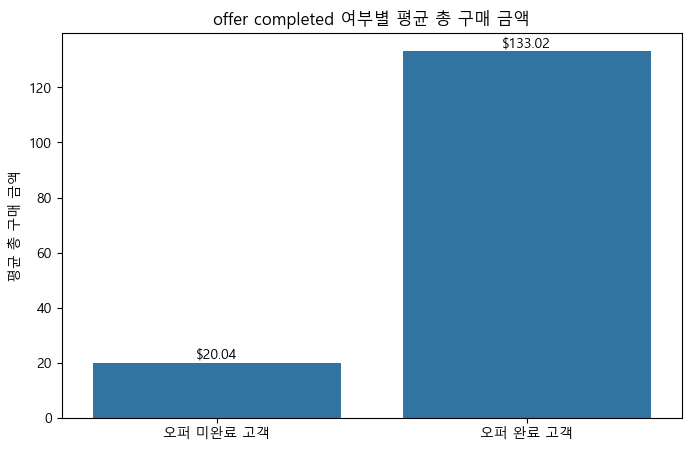

In [200]:
# offer completed 여부별 평균 총 구매 금액
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=offer_compare, x='offer_completed', y='평균총구매금액')

for i, v in enumerate(offer_compare['평균총구매금액']):
    ax.text(i, v+0.5, f"${v:,.2f}", ha='center', va='bottom')

plt.title('offer completed 여부별 평균 총 구매 금액')
plt.xlabel('')
plt.ylabel('평균 총 구매 금액')
plt.show()

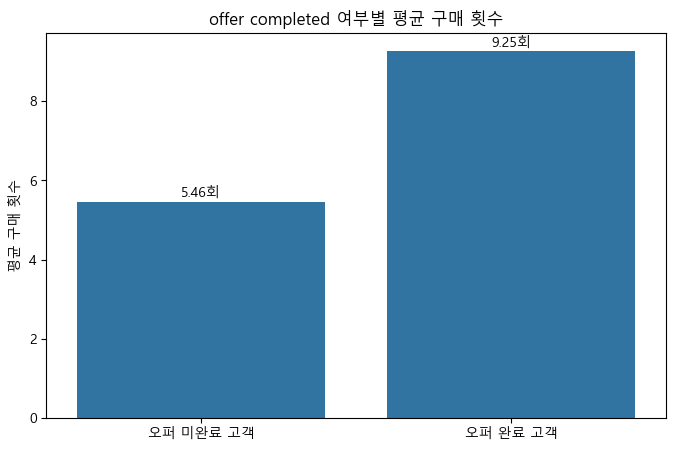

In [201]:
# offer completed 여부별 평균 구매 횟수
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=offer_compare, x='offer_completed', y='평균구매횟수')

for i, v in enumerate(offer_compare['평균구매횟수']):
    ax.text(i, v+0.05, f"{v:,.2f}회", ha='center', va='bottom')

plt.title('offer completed 여부별 평균 구매 횟수')
plt.xlabel('')
plt.ylabel('평균 구매 횟수')
plt.show()